# Diabetes Risk Predictor
### Exploratory Data Analysis, Feature Engineering, Model Building & Interpretability

**Dataset:** Pima Indians Diabetes Dataset  
**Goal:** Predict likelihood of diabetes based on diagnostic measurements  
**Disclaimer:** For educational purposes only. Not a substitute for professional medical advice.

# Import and load dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
import joblib
import json

In [12]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
print(df.shape)
print(df.info())
print(df.describe())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std      

## Step 1: Data Quality Check
Several columns (Glucose, BloodPressure, SkinThickness, Insulin, BMI) have **zero values that are biologically impossible** — these are actually missing data encoded as 0.

In [14]:
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_invalid_zeros:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values ({zero_count/len(df)*100:.1f}%)")

Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


In [15]:
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## Step 2: Exploratory Data Analysis

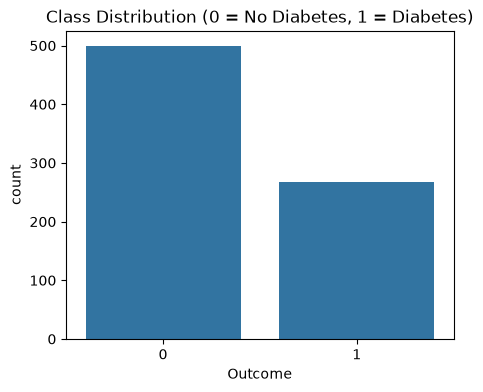

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', data=df)
plt.title("Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.show()

print(df['Outcome'].value_counts(normalize=True))

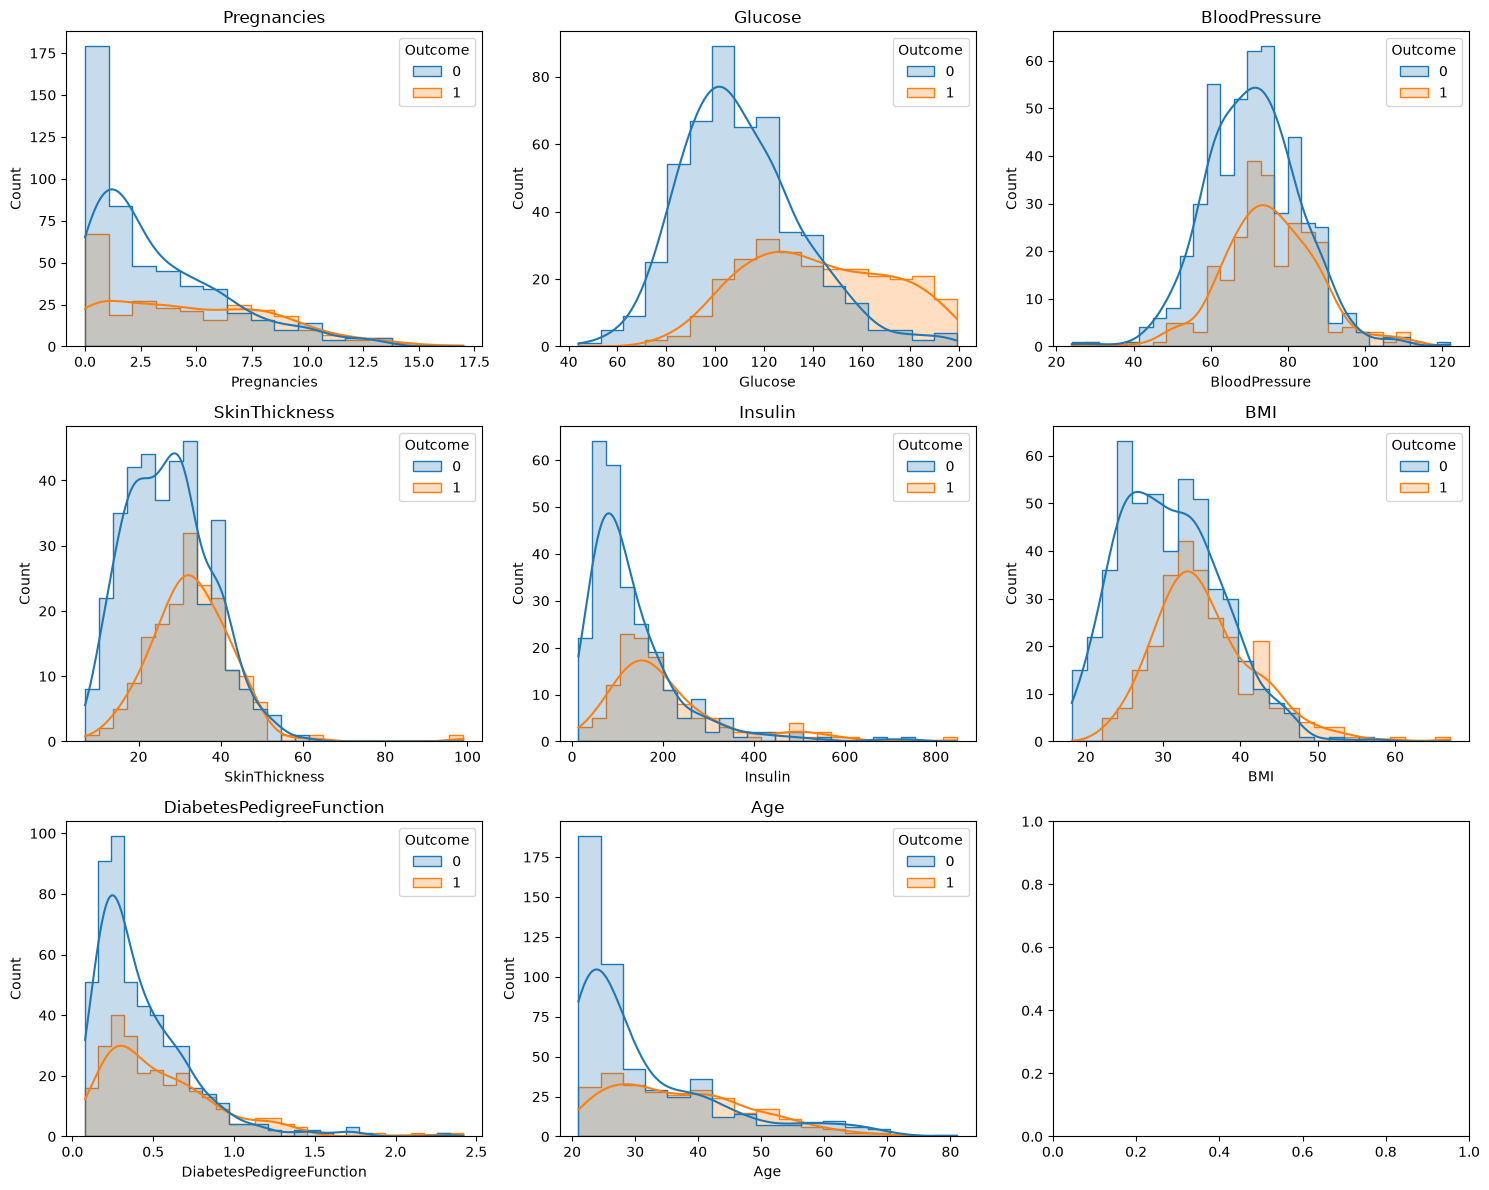

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i], element='step')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

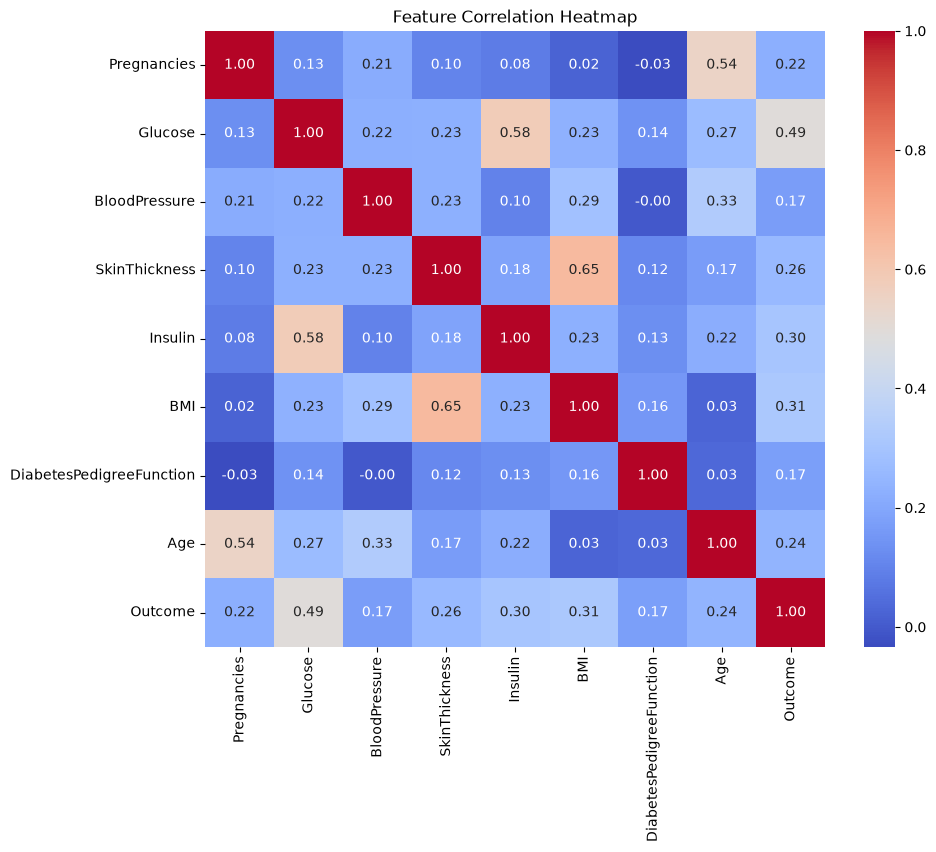

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

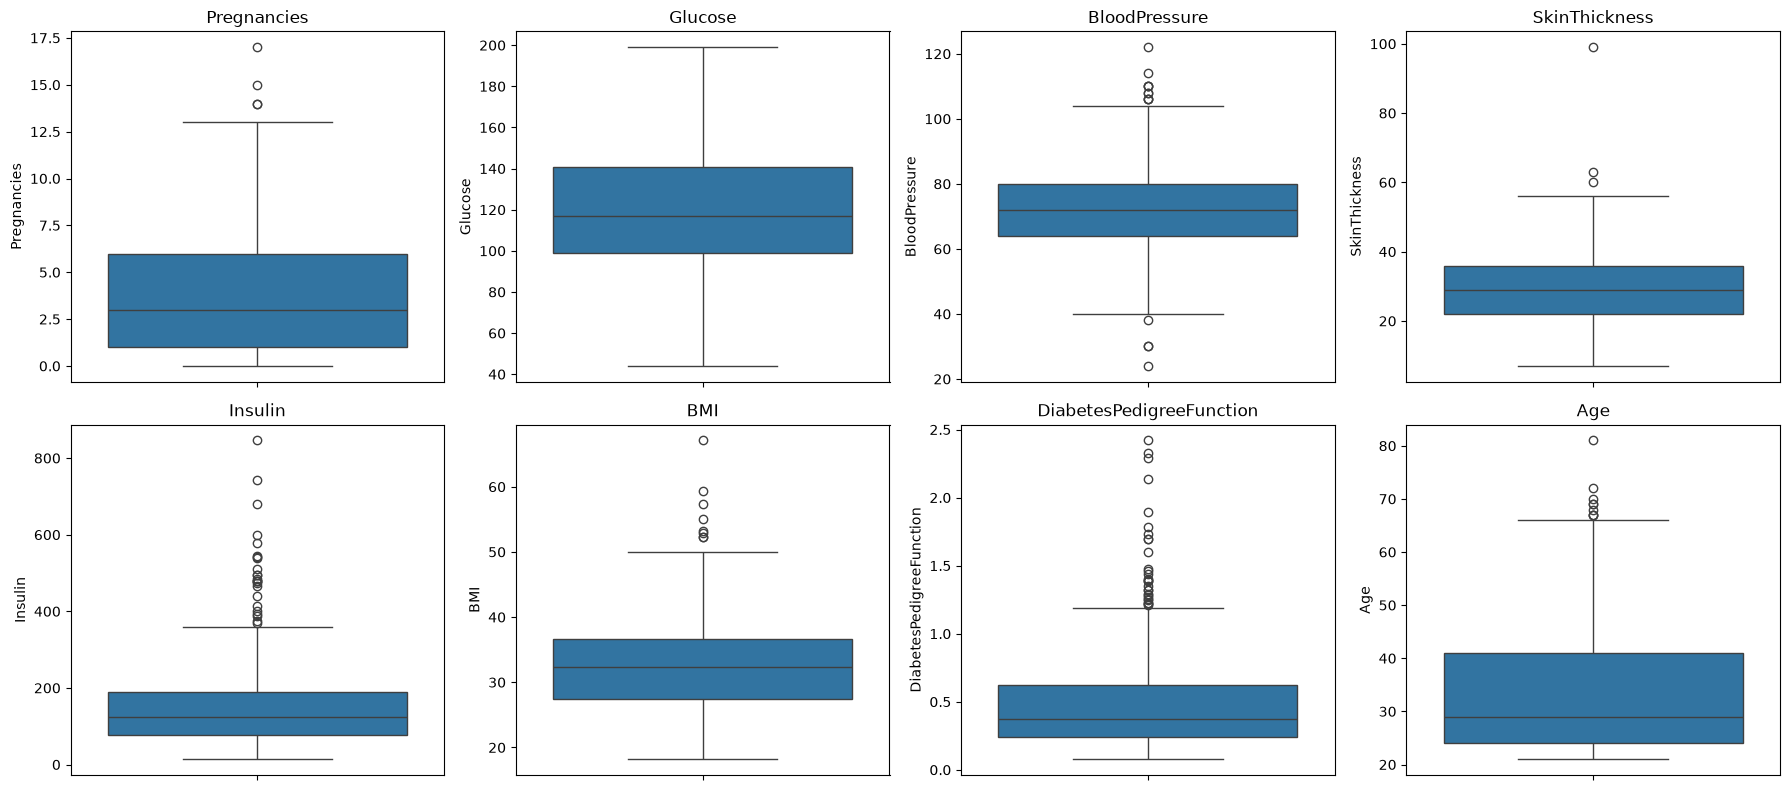

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Step 3: Handle Missing Values (KNN Imputation)
Using KNN imputation instead of simple mean/median since it preserves relationships between correlated features (e.g., Glucose and Insulin).

In [20]:
# fit imputer on features only, not on Outcome
feature_cols = df.columns.drop('Outcome')
imputer = KNNImputer(n_neighbors=5)
df_imputed_features = pd.DataFrame(imputer.fit_transform(df[feature_cols]), columns=feature_cols)
df_imputed = df_imputed_features.copy()
df_imputed['Outcome'] = df['Outcome'].values

df_imputed.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Step 4: Feature Engineering

In [21]:
# BMI categories
def bmi_category(bmi):
    if bmi < 18.5: return 0  # Underweight
    elif bmi < 25: return 1  # Normal
    elif bmi < 30: return 2  # Overweight
    else: return 3            # Obese

df_imputed['BMI_Category'] = df_imputed['BMI'].apply(bmi_category)

# Age groups
def age_group(age):
    if age < 30: return 0
    elif age < 45: return 1
    elif age < 60: return 2
    else: return 3

df_imputed['Age_Group'] = df_imputed['Age'].apply(age_group)

# Glucose risk flag
df_imputed['High_Glucose'] = (df_imputed['Glucose'] > 140).astype(int)

df_imputed.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,High_Glucose
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1,3,2,1
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0,2,1,0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1,1,1,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,2,0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,3,1,0


## Step 5: Train/Test Split + Scaling

In [22]:
FEATURE_NAMES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age',
                 'BMI_Category', 'Age_Group', 'High_Glucose']

X = df_imputed[FEATURE_NAMES]
y = df_imputed['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (614, 11), Test shape: (154, 11)


## Step 6: Handle Class Imbalance with SMOTE

Implemented from scratch with `sklearn`'s `NearestNeighbors` (identical idea to `imblearn.SMOTE`: interpolate between a minority sample and one of its nearest minority neighbors) so the whole project only depends on `scikit-learn` — no extra install needed to reproduce this notebook or run the app.

In [23]:
def smote_oversample(X, y, k=5, random_state=42):
    """Minimal SMOTE: oversamples the minority class by interpolating
    between each minority point and a randomly chosen k-nearest minority neighbor."""
    rng = np.random.RandomState(random_state)
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    min_class = classes[np.argmin(counts)]
    n_needed = counts.max() - counts.min()
    X_min = X[y == min_class]

    n_neighbors = min(k + 1, len(X_min))
    nn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_min)
    neighbor_idx = nn.kneighbors(X_min, return_distance=False)[:, 1:]  # drop self-match

    synthetic = np.zeros((n_needed, X.shape[1]))
    for i in range(n_needed):
        base_idx = rng.randint(0, len(X_min))
        chosen_neighbor = neighbor_idx[base_idx][rng.randint(0, neighbor_idx.shape[1])]
        gap = rng.rand()
        synthetic[i] = X_min[base_idx] + gap * (X_min[chosen_neighbor] - X_min[base_idx])

    X_res = np.vstack([X, synthetic])
    y_res = np.concatenate([y, np.full(n_needed, min_class)])
    return X_res, y_res

X_train_res, y_train_res = smote_oversample(X_train_scaled, y_train.values, k=5)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 400, 1: 214}
After SMOTE: {0: 400, 1: 400}


## Step 7: Model Building — Logistic Regression

In [24]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.86      0.73      0.79       100
           1       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154

ROC-AUC: 0.8253703703703703


## Step 8: Linear Regression (as a baseline)

Linear Regression isn't built for classification, but it's a useful baseline to compare against: fit directly on the 0/1 `Outcome` column, then clip the raw output to `[0, 1]` and treat it as a pseudo-probability.

In [25]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_res, y_train_res)

y_prob_linreg = np.clip(lin_reg.predict(X_test_scaled), 0, 1)
y_pred_linreg = (y_prob_linreg >= 0.5).astype(int)

print(classification_report(y_test, y_pred_linreg))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_linreg))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79       100
           1       0.61      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.75      0.75       154

ROC-AUC: 0.8237037037037036


## Step 9: Random Forest

In [26]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.85      0.73      0.78       100
           1       0.60      0.76      0.67        54

    accuracy                           0.74       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.74      0.75       154

ROC-AUC: 0.8333333333333334


## Step 10: Decision Tree

In [27]:
dtree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
dtree.fit(X_train_res, y_train_res)

y_pred_dt = dtree.predict(X_test_scaled)
y_prob_dt = dtree.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

           0       0.88      0.74      0.80       100
           1       0.63      0.81      0.71        54

    accuracy                           0.77       154
   macro avg       0.75      0.78      0.76       154
weighted avg       0.79      0.77      0.77       154

ROC-AUC: 0.8187037037037037


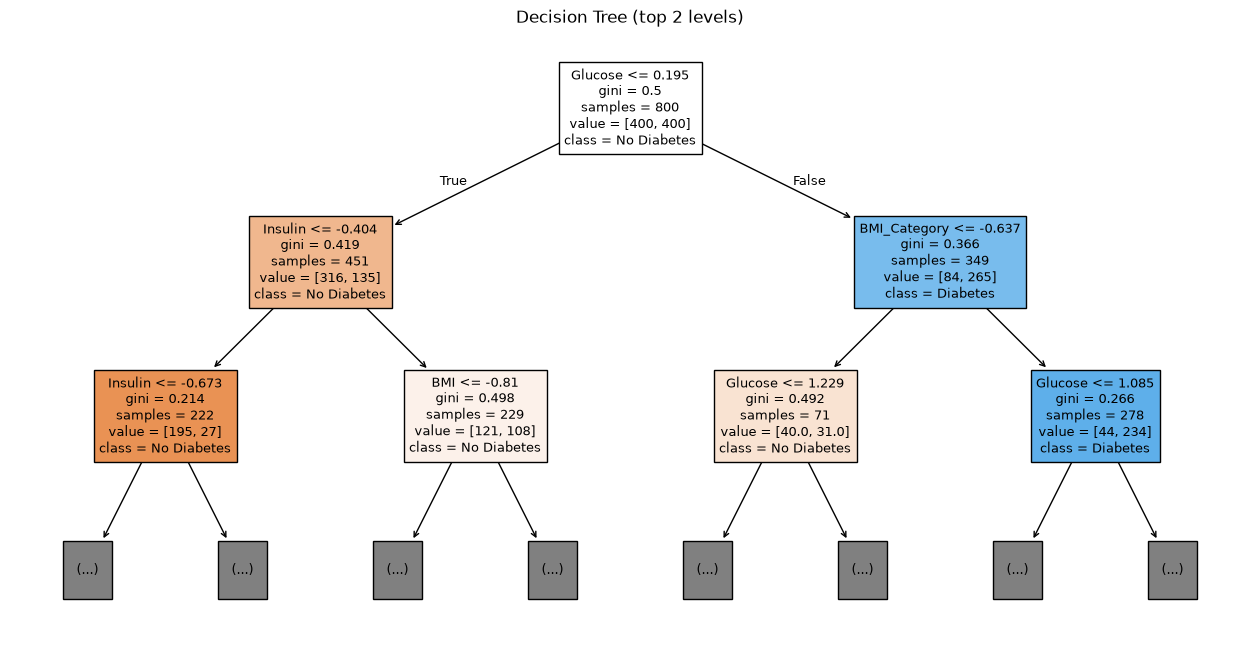

In [28]:
plt.figure(figsize=(16, 8))
plot_tree(dtree, feature_names=FEATURE_NAMES, class_names=['No Diabetes', 'Diabetes'],
          filled=True, max_depth=2, fontsize=9)
plt.title("Decision Tree (top 2 levels)")
plt.show()

## Step 11: Compare All 4 Models — ROC Curves

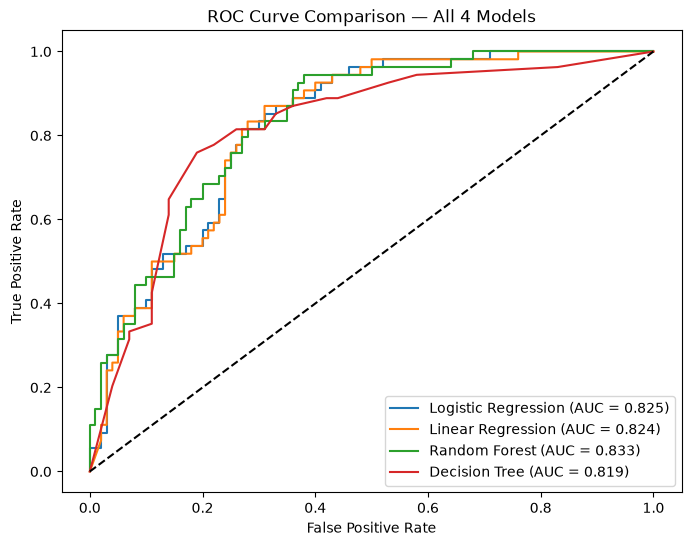

In [29]:
plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', y_prob_lr),
                      ('Linear Regression', y_prob_linreg),
                      ('Random Forest', y_prob_rf),
                      ('Decision Tree', y_prob_dt)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All 4 Models")
plt.legend()
plt.show()

## Step 12: Full Metrics Table + Confusion Matrices

In [30]:
models = {
    'Logistic Regression': (log_reg, y_prob_lr),
    'Linear Regression': (lin_reg, y_prob_linreg),
    'Random Forest': (rf, y_prob_rf),
    'Decision Tree': (dtree, y_prob_dt),
}

metrics = {}
roc_data = {}
for name, (model, probs) in models.items():
    preds = (probs >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, probs)
    metrics[name] = {
        "accuracy": round(accuracy_score(y_test, preds), 4),
        "precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "f1": round(f1_score(y_test, preds, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, probs), 4),
    }
    metrics[name]["confusion_matrix"] = confusion_matrix(y_test, preds).tolist()
    roc_data[name] = {"fpr": fpr.tolist(), "tpr": tpr.tolist()}

metrics_df = pd.DataFrame(metrics).T[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
metrics_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7468,0.6087,0.7778,0.6829,0.8254
Linear Regression,0.7468,0.6119,0.7593,0.6777,0.8237
Random Forest,0.7403,0.6029,0.7593,0.6721,0.8333
Decision Tree,0.7662,0.6286,0.8148,0.7097,0.8187


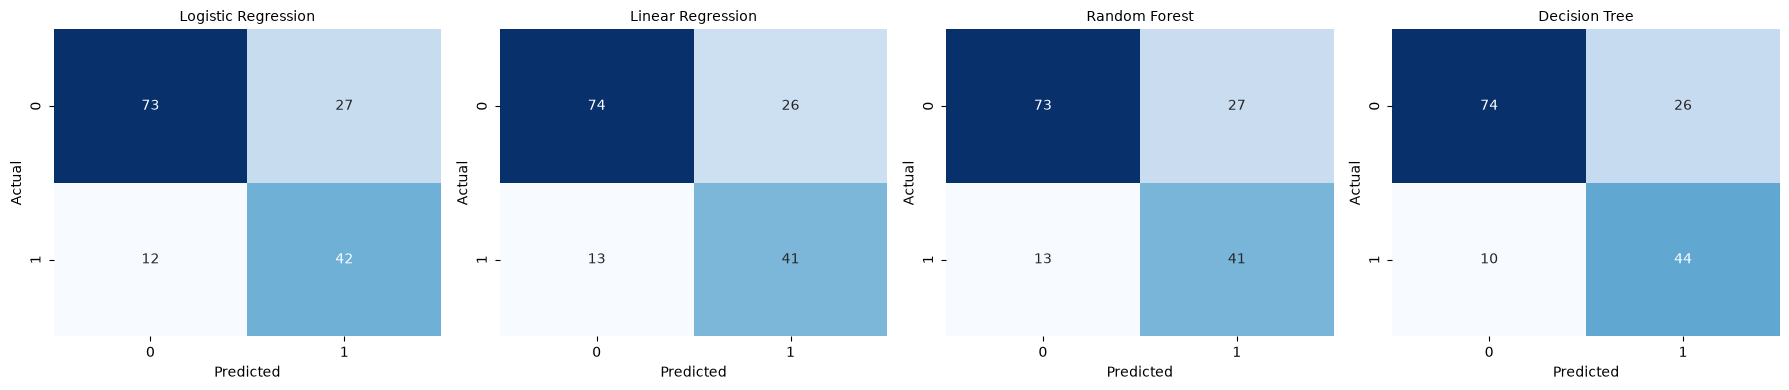

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, (model, probs)) in zip(axes, models.items()):
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## Step 13: Feature Importance per Model

For the linear models, importance is `|coefficient|` on the scaled features. For the tree models, it's each model's built-in `feature_importances_`.

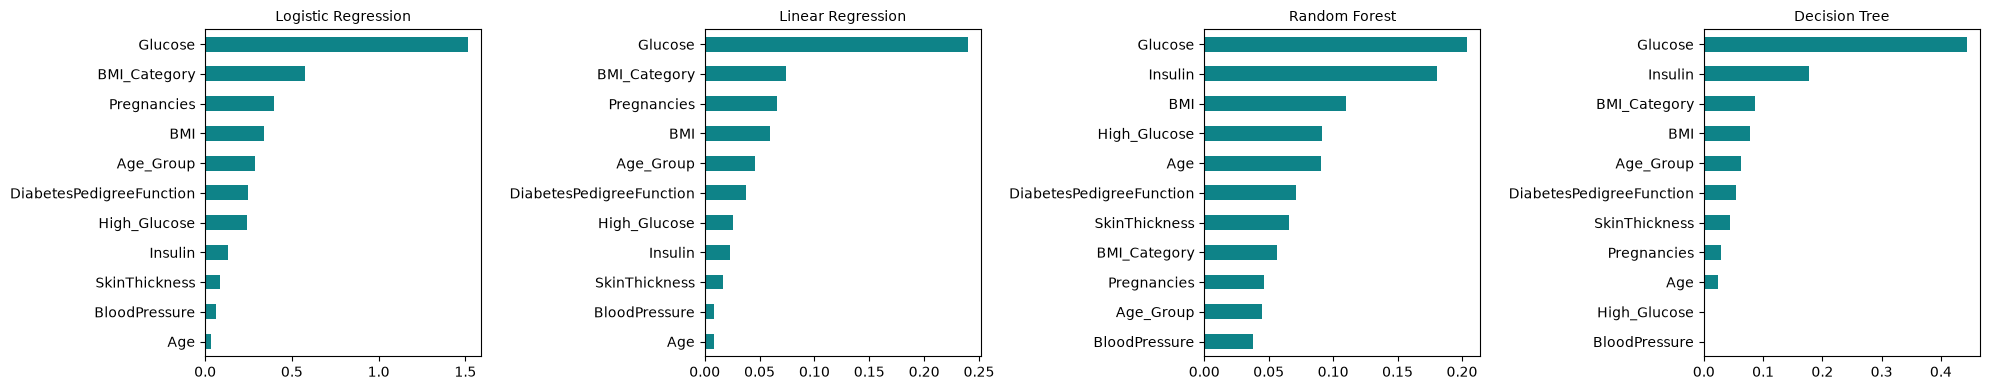

In [32]:
feature_importance = {
    'Logistic Regression': dict(zip(FEATURE_NAMES, np.abs(log_reg.coef_[0]).round(4).tolist())),
    'Linear Regression': dict(zip(FEATURE_NAMES, np.abs(lin_reg.coef_).round(4).tolist())),
    'Random Forest': dict(zip(FEATURE_NAMES, rf.feature_importances_.round(4).tolist())),
    'Decision Tree': dict(zip(FEATURE_NAMES, dtree.feature_importances_.round(4).tolist())),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, importances) in zip(axes, feature_importance.items()):
    s = pd.Series(importances).sort_values()
    s.plot.barh(ax=ax, color='#0E8388')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

## Step 14: Explainability (per-prediction, dependency-free)

Instead of SHAP (an extra dependency), this uses a simple, transparent leave-one-out-from-baseline method that works identically for every model type: replace one feature at a time with its **training-set mean** (in scaled space), re-predict, and the resulting change in predicted probability is that feature's contribution to this specific prediction. This is exactly what the Streamlit app uses on the Predictor page.

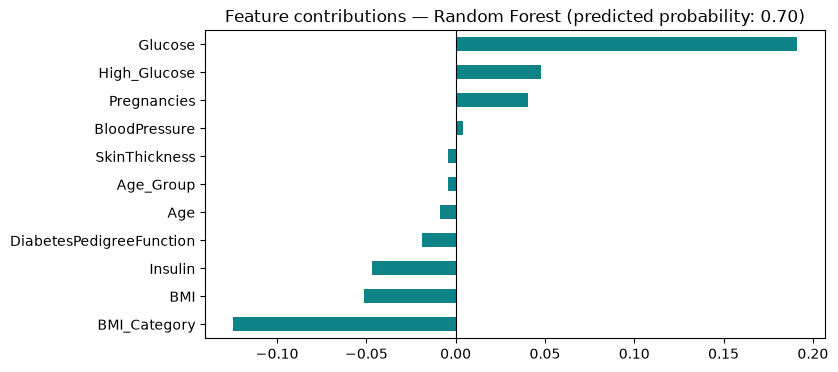

In [33]:
baseline_means = X_train_scaled.mean(axis=0)

def explain_prediction(model, x_scaled, model_name, baseline=baseline_means):
    def predict_fn(row):
        if model_name == 'Linear Regression':
            return np.clip(model.predict(row.reshape(1, -1))[0], 0, 1)
        return model.predict_proba(row.reshape(1, -1))[0][1]

    full_pred = predict_fn(x_scaled)
    contributions = {}
    for i, name in enumerate(FEATURE_NAMES):
        perturbed = x_scaled.copy()
        perturbed[i] = baseline[i]
        contributions[name] = full_pred - predict_fn(perturbed)
    return contributions, full_pred

# demo on one test-set row
sample = X_test_scaled[0]
contribs, pred = explain_prediction(rf, sample, 'Random Forest')
pd.Series(contribs).sort_values().plot.barh(figsize=(8, 4), color='#0E8388')
plt.title(f"Feature contributions — Random Forest (predicted probability: {pred:.2f})")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## Step 15: Save All 4 Models & Preprocessing Objects for the App

In [34]:
joblib.dump(log_reg, 'diabetes_logreg.pkl')
joblib.dump(lin_reg, 'diabetes_linreg.pkl')
joblib.dump(rf, 'diabetes_rf.pkl')
joblib.dump(dtree, 'diabetes_dtree.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')
joblib.dump(imputer, 'diabetes_imputer.pkl')

with open('model_metrics.json', 'w') as f:
    json.dump({
        'metrics': metrics,
        'roc_data': roc_data,
        'feature_importance': feature_importance,
        'feature_names': FEATURE_NAMES,
        'baseline_means': baseline_means.tolist(),
    }, f, indent=2)

print('Saved: diabetes_logreg.pkl, diabetes_linreg.pkl, diabetes_rf.pkl, diabetes_dtree.pkl,')
print('       diabetes_scaler.pkl, diabetes_imputer.pkl, model_metrics.json')

Saved: diabetes_logreg.pkl, diabetes_linreg.pkl, diabetes_rf.pkl, diabetes_dtree.pkl,
       diabetes_scaler.pkl, diabetes_imputer.pkl, model_metrics.json
